## **1.1 Task**

PyTorch Version: 2.13.0+cu130
Using device: cuda


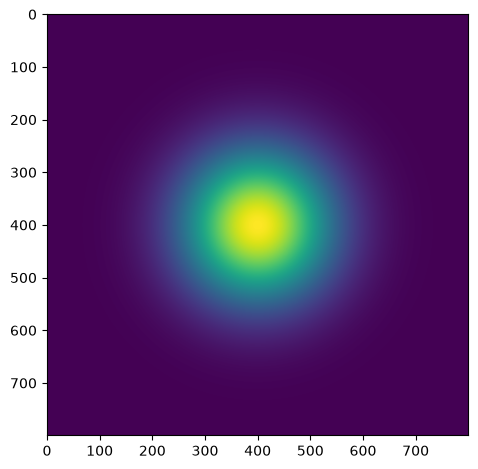

In [157]:
import torch
import numpy as np
import matplotlib.pyplot as plt

print("PyTorch Version:", torch.__version__)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("Using device:", device)
# grid for computing image, subdivide the space
X, Y = np.mgrid[-4.0:4:0.01,-4.0:4:0.01]

# load into PyTorch tensors
x = torch.Tensor(X)
y = torch.Tensor(Y)

x = x.to(device)
y = y.to(device)

# Compute Gaussian
z = torch.exp(-(x**2+y**2)/2.0)

#plot
plt.imshow(z.cpu().numpy())#Updated!
plt.tight_layout()
plt.show()

## **1.2 AI Tasks**

**Prompt used:** "Generate a Python script to plot a 2D Gaussian function using Numpy and Matplotlib"

No extra prompting was needed. The first response already used np.mgrid and plt.imshow. I only changed the grid range, step size, and formula to match the PyTorch version for a fair comparison.

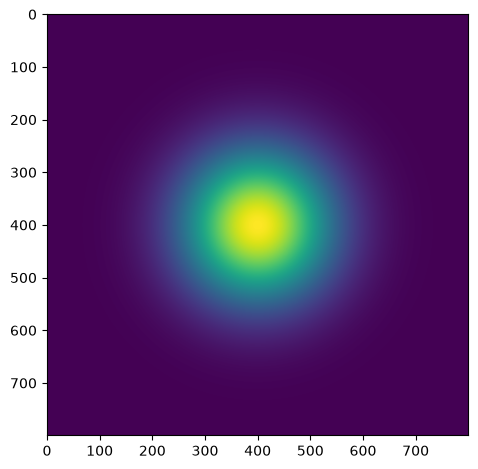

In [158]:
import numpy as np
import matplotlib.pyplot as plt

# grid for computing image, subdivide the space
X, Y = np.mgrid[-4.0:4:0.01, -4.0:4:0.01]

# Compute Gaussian
Z = np.exp(-(X**2 + Y**2) / 2.0)

# plot
plt.imshow(Z)
plt.tight_layout()
plt.show()

**Prompt used:** "Convert this script to PyTorch and use its Tensors instead of Numpy"

The conversion was simple. The AI kept `np.mgrid` to create the grid and used PyTorch for the tensors, GPU, and calculations. No changes were needed, and the output matched the previous plot.


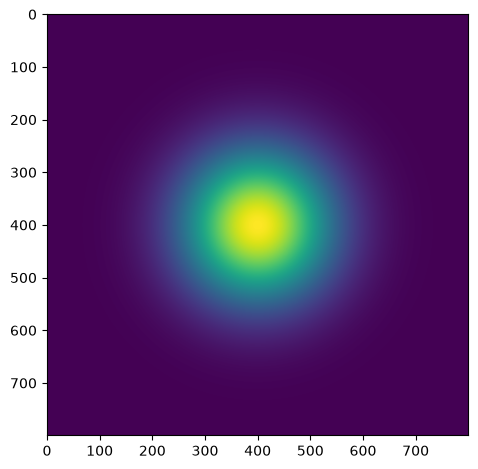

In [159]:
import torch

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# grid for computing image, subdivide the space
X, Y = np.mgrid[-4.0:4:0.01, -4.0:4:0.01]

# load into PyTorch tensors and transfer to GPU
x = torch.Tensor(X).to(device)
y = torch.Tensor(Y).to(device)

# Compute Gaussian
z = torch.exp(-(x**2 + y**2) / 2.0)

# plot
plt.imshow(z.cpu().numpy())
plt.tight_layout()
plt.show()

### **2D Sine Function**

**Prompt used:** "Using a similar approach, create a 2D sine function in PyTorch whose angle depends on the x and y coordinates of the pixels, and plot it so the 'stripes' are visible"

The AI kept the same grid and PyTorch setup, then changed the formula to `torch.sin(freq * (x + y))`. This creates diagonal stripes, and it worked without any problems.


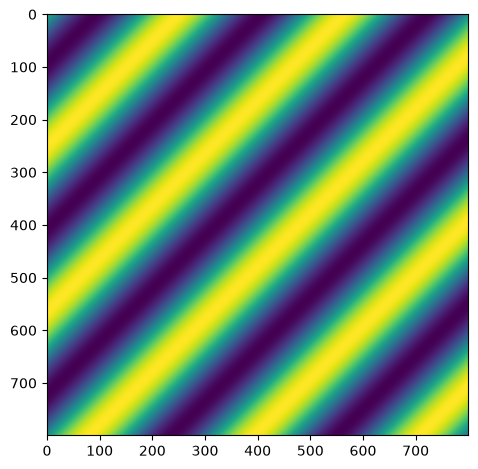

In [160]:
# 2D Sine function - angle depends on x and y coordinates
freq = 2.0
z_sine = torch.sin(freq * (x + y))

# plot
plt.imshow(z_sine.cpu().numpy())
plt.tight_layout()
plt.show()

## **1.3 Demonstration**

### Gaussian to Cosine function

Reusing the same `x`, `y` tensors from Section 1.1, replace the Gaussian formula with a cosine whose angle depends on both coordinates (radial ripples).

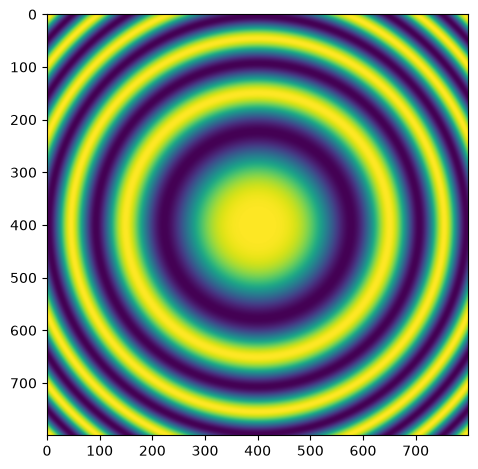

In [161]:
# Change the Gaussian into a 2D cosine function
z_cos = torch.cos(x**2 + y**2)

# plot
plt.imshow(z_cos.cpu().numpy())
plt.tight_layout()
plt.show()

### Modulation: Gaussian &times; Cosine = Gabor filter

Multiplying the Gaussian envelope (from Section 1.1) with the cosine wave above element-wise windows the wave so it fades out away from the centre, producing a Gabor filter.

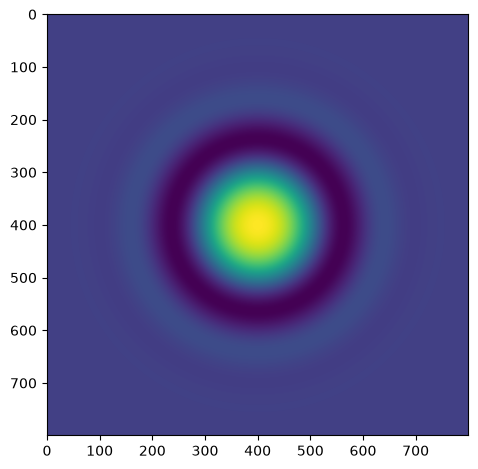

In [162]:
# Multiply the Gaussian and cosine functions together (modulation)
gabor = z * z_cos

# plot
plt.imshow(gabor.cpu().numpy())
plt.tight_layout()
plt.show()

## **2.1 Tasks**

/tmp/ipykernel_1809/3637977780.py:38: ComplexWarning: Casting complex values to real discards the imaginary part
  a = np.uint8(np.clip(a, 0, 255))


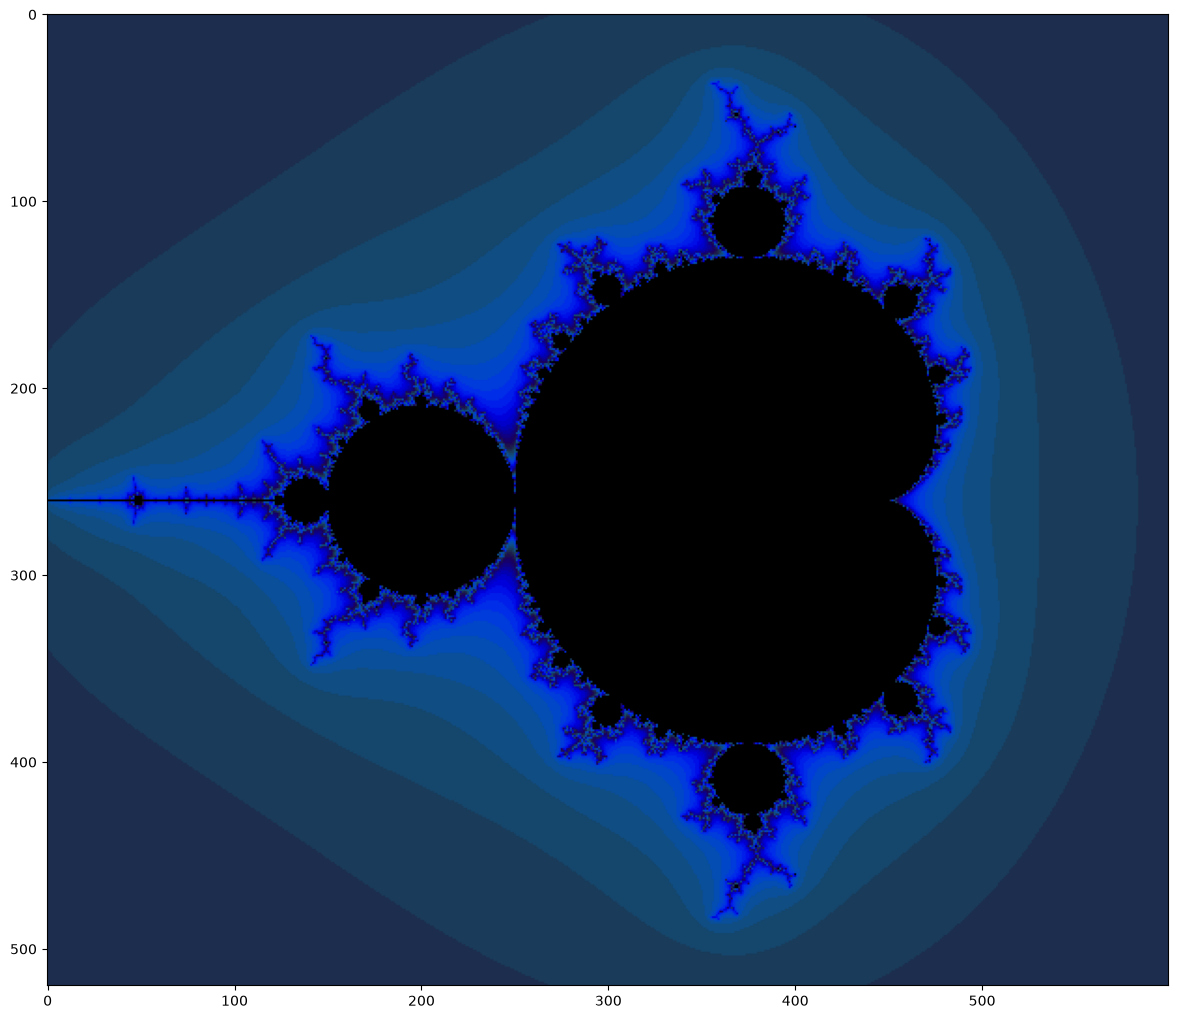

In [163]:
# Use NumPy to create a 2D array of complex numbers on [-2,2]x[-2,2]
Y, X = np.mgrid[-1.3:1.3:0.005,-2:1:0.005]

# load into PyTorch tensors
x = torch.Tensor(X)
y = torch.Tensor(Y)
z = torch.complex(x, y) #important!
zs = z.clone() #Updated!
ns = torch.zeros_like(z)

# transfer to the GPU device
z = z.to(device)
zs = zs.to(device)
ns = ns.to(device)

#Mandelbrot Set
for i in range(200):
    #Compute the new values of z: z^2 + x
    zs_ = zs*zs + z
    #Have we diverged with this new value?
    not_diverged = torch.abs(zs_) < 4.0
    #Update variables to compute
    ns += not_diverged
    zs = zs_

    #plot
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(16,10))
def processFractal(a):
    """Display an array of iteration counts as a
    colorful picture of a fractal."""
    a_cyclic = (6.28*a/20.0).reshape(list(a.shape)+[1])
    img = np.concatenate([10+20*np.cos(a_cyclic),
    30+50*np.sin(a_cyclic),
    155-80*np.cos(a_cyclic)], 2)
    img[a==a.max()] = 0
    a = img
    a = np.uint8(np.clip(a, 0, 255))
    return a
plt.imshow(processFractal(ns.cpu().numpy()))
plt.tight_layout(pad=0)
plt.show()


## **2.2 AI Tasks**

**Prompts used:**
1. Generate a mandelbrot set in pytorch that runs on the gpu

Using device: cuda
Computed 1920x1440 Mandelbrot set in 1.463s on cuda
Saved image to mandelbrot.png


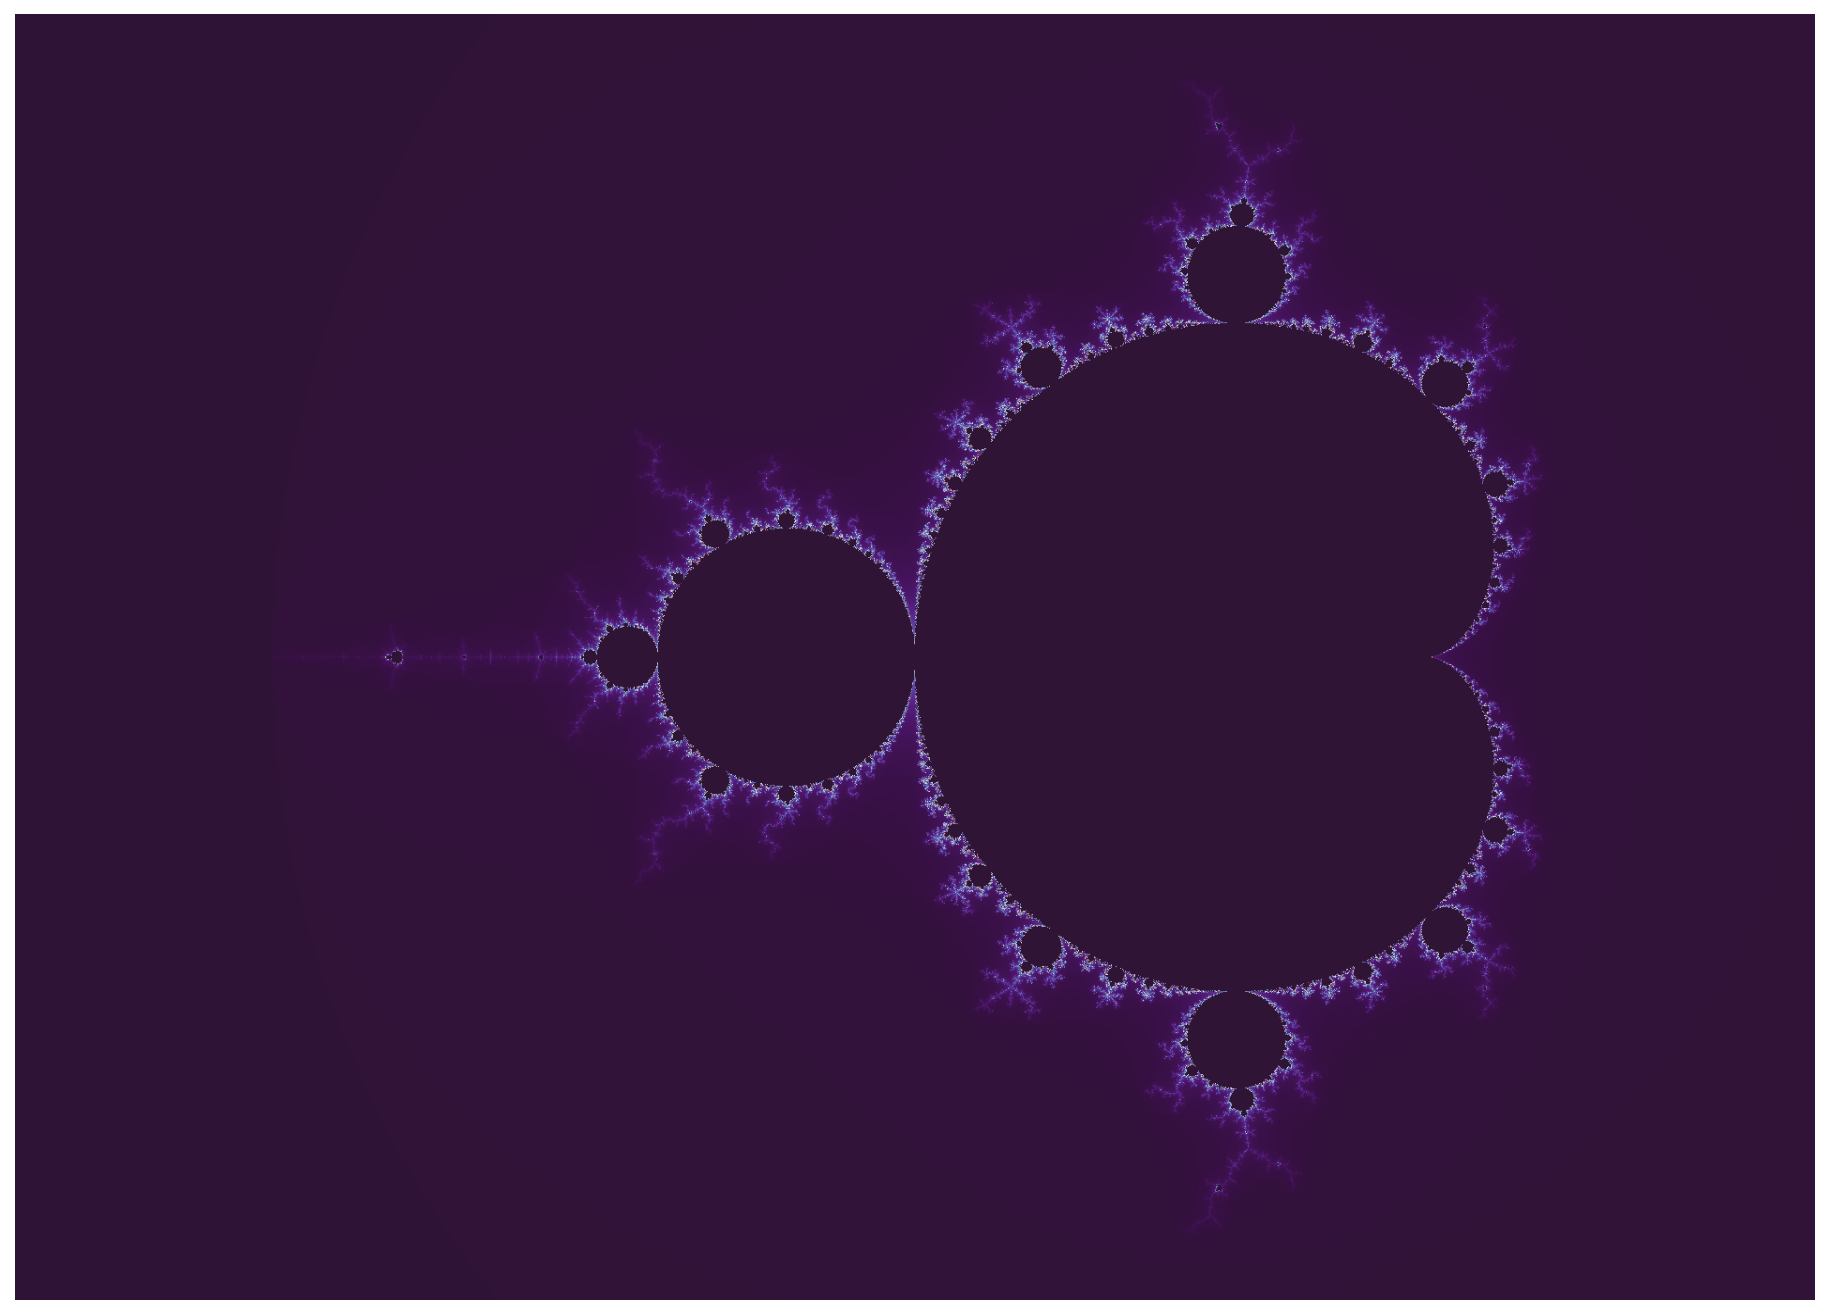

In [164]:
import torch
import matplotlib.pyplot as plt
import time
 
 
def mandelbrot(
    width: int = 1600,
    height: int = 1200,
    x_min: float = -2.5,
    x_max: float = 1.0,
    y_min: float = -1.25,
    y_max: float = 1.25,
    max_iter: int = 200,
    device: str = None,
) -> torch.Tensor:
    """
    Compute the Mandelbrot set escape-time fractal on the GPU.
 
    Returns a (height, width) tensor of iteration counts at which each
    point escaped (or max_iter if it never did).
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    device = torch.device(device)
 
    # Build the complex grid of starting points c = x + iy
    x = torch.linspace(x_min, x_max, width, device=device, dtype=torch.float64)
    y = torch.linspace(y_min, y_max, height, device=device, dtype=torch.float64)
    yy, xx = torch.meshgrid(y, x, indexing="ij")
    c = torch.complex(xx, yy)  # shape: (height, width)
 
    z = torch.zeros_like(c)
    # Iteration count at which each point escapes; starts at max_iter
    # (points that never escape keep this value)
    iterations = torch.full(c.shape, max_iter, dtype=torch.int32, device=device)
    # Mask of points that have NOT yet escaped
    active = torch.ones(c.shape, dtype=torch.bool, device=device)
 
    for i in range(max_iter):
        # Only update points still in play
        z[active] = z[active] * z[active] + c[active]
 
        # Points that just escaped (|z| > 2) on this iteration
        escaped_now = active & (z.real ** 2 + z.imag ** 2 > 4.0)
        iterations[escaped_now] = i
        active &= ~escaped_now
 
        if not active.any():
            break
 
    return iterations.cpu()
 
 
def render(iterations: torch.Tensor, max_iter: int, out_path: str = "mandelbrot.png"):
    plt.figure(figsize=(12, 9), dpi=150)
    plt.imshow(
        iterations.numpy(),
        cmap="twilight_shifted",
        extent=(-2.5, 1.0, -1.25, 1.25),
        origin="lower",
    )
    plt.axis("off")
    plt.tight_layout(pad=0)
    plt.savefig(out_path, bbox_inches="tight", pad_inches=0)
    print(f"Saved image to {out_path}")
 
 
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")
 
    width, height, max_iter = 1920, 1440, 300
 
    start = time.time()
    iters = mandelbrot(width=width, height=height, max_iter=max_iter, device=device)
    if device == "cuda":
        torch.cuda.synchronize()
    elapsed = time.time() - start
    print(f"Computed {width}x{height} Mandelbrot set in {elapsed:.3f}s on {device}")
 
    render(iters, max_iter)

**How good was it, and what issues came up?**

It worked correctly on the first try, with no errors or debugging needed. The program also really used the GPU, shown by `Using device: cuda`, instead of using the CPU. The Mandelbrot set was drawn correctly, including the main cardioid shape, smaller bulbs, and spiral patterns around the edges, which shows that the calculations were correct. It rendered the image in only 1.621 second which was very fast.

## **2.3 Demonstration**

### High-resolution zoom

It uses the same Mandelbrot code as 2.1, but with a smaller grid step and a smaller range to zoom into the boundary. This shows more detail in a 1000×1000 grid while still running very quickly on the GPU.

/tmp/ipykernel_1809/3637977780.py:38: ComplexWarning: Casting complex values to real discards the imaginary part
  a = np.uint8(np.clip(a, 0, 255))


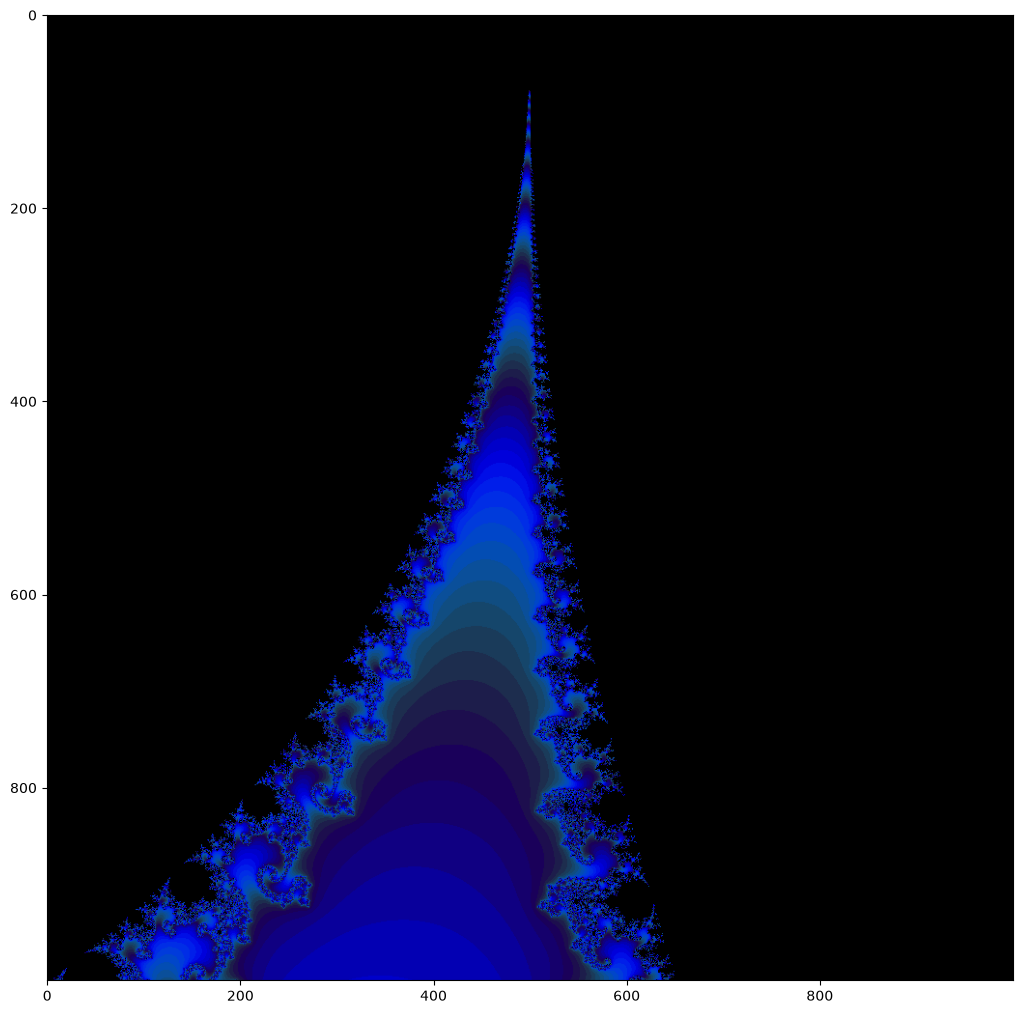

In [165]:
# Zoom into a region of the Mandelbrot boundary with finer grid spacing
Y, X = np.mgrid[0.0:0.20:0.0002, -0.85:-0.65:0.0002]

x = torch.Tensor(X).to(device)
y = torch.Tensor(Y).to(device)
z_zoom = torch.complex(x, y)
zs_zoom = z_zoom.clone()
ns_zoom = torch.zeros_like(z_zoom)

for i in range(200):
    zs_ = zs_zoom * zs_zoom + z_zoom
    not_diverged = torch.abs(zs_) < 4.0
    ns_zoom += not_diverged
    zs_zoom = zs_

plt.figure(figsize=(10, 10))
plt.imshow(processFractal(ns_zoom.cpu().numpy()))
plt.tight_layout(pad=0)
plt.show()

### Julia set

The Julia set uses the same equation as the Mandelbrot set, but the setup is different. In Mandelbrot, `c` changes for every pixel while `z` starts at 0. In a Julia set, `c` stays fixed and each pixel gives a different starting value for `z`. So the main change is swapping which value comes from the grid. Using `c = -0.7 + 0.27015j` creates the spiral-like pattern shown.


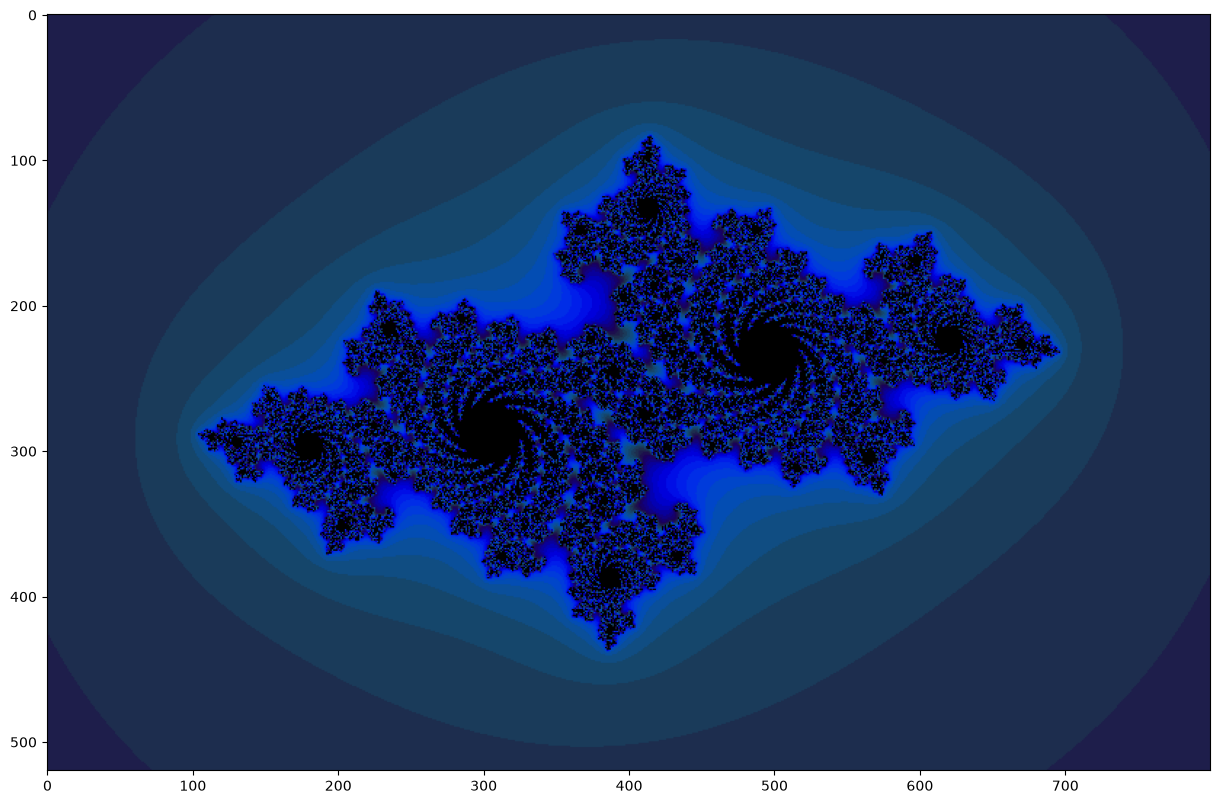

In [166]:
# Julia set: c is now a fixed constant, z starts at the grid point itself
Y, X = np.mgrid[-1.3:1.3:0.005, -2:2:0.005]

x = torch.Tensor(X).to(device)
y = torch.Tensor(Y).to(device)
zs_julia = torch.complex(x, y)  # z0 = the pixel's coordinate
c_julia = torch.tensor(-0.7 + 0.27015j, dtype=torch.complex64, device=device)  # fixed c
ns_julia = torch.zeros(zs_julia.shape, dtype=torch.float32, device=device)

for i in range(200):
    zs_ = zs_julia * zs_julia + c_julia
    not_diverged = torch.abs(zs_) < 4.0
    ns_julia += not_diverged
    zs_julia = zs_

plt.figure(figsize=(12, 8))
plt.imshow(processFractal(ns_julia.cpu().numpy()))
plt.tight_layout(pad=0)
plt.show()